# External Inputs

$$\def\RR{\mathbb{R}}
\def\NN{\mathbb{N}}
\def\ZZ{\mathbb{Z}}
\def\I{\mathbf{I}}
\def\0{\mathbf{0}}
\def\1{\mathbf{1}}
\def\q{\mathbf{q}}
\def\u{\mathbf{u}}
\def\z{\mathbf{z}}
\def\d{\mathbf{d}}
\def\f{\mathbf{f}}
\def\s{\mathbf{s}}
\def\Q{\mathbf{Q}}
\def\U{\mathbf{U}}
\def\Z{\mathbf{Z}}
\def\Op{\mathbf{f}}
\def\Ophat{\hat{\mathbf{f}}}
\def\c{\mathbf{c}}
\def\A{\mathbf{A}}
\def\H{\mathbf{H}}
\def\G{\mathbf{G}}
\def\B{\mathbf{B}}
\def\N{\mathbf{N}}
\def\v{\mathbf{v}}
\def\w{\mathbf{w}}
\def\V{\mathbf{V}}
\def\W{\mathbf{W}}
\def\Vr{\mathbf{V}_{\!r}}
\def\Wr{\mathbf{W}_{\!r}}
\def\qhat{\hat{\mathbf{q}}}
\def\zhat{\hat{\mathbf{z}}}
\def\fhat{\hat{\mathbf{f}}}
\def\Qhat{\hat{\mathbf{Q}}}
\def\Zhat{\hat{\mathbf{Z}}}
\def\chat{\hat{\mathbf{c}}}
\def\Ahat{\hat{\mathbf{A}}}
\def\Hhat{\hat{\mathbf{H}}}
\def\Ghat{\hat{\mathbf{G}}}
\def\Bhat{\hat{\mathbf{B}}}
\def\Nhat{\hat{\mathbf{N}}}
\def\D{\mathbf{D}}
\def\ohat{\hat{\mathbf{o}}}
\def\Ohat{\hat{\mathbf{O}}}
\def\bfmu{\boldsymbol{\mu}}
\def\bfGamma{\boldsymbol{\Gamma}}
\def\bfPhi{\boldsymbol{\Phi}}
\def\bfSigma{\boldsymbol{\Sigma}}
\def\bfPsi{\boldsymbol{\Psi}}
\def\bfLambda{\boldsymbol{\Lambda}}
\def\bfxi{\boldsymbol{\xi}}
\def\trp{{^{\mathsf{T}}}}
\def\ddt{\frac{\textrm{d}}{\textrm{d}t}}
\def\ddqhat{\frac{\partial}{\partial\qhat}}
\def\mean{\operatorname{mean}}
\def\std{\operatorname{std}}
\def\argmin{\operatorname{argmin}}$$

The fundamental goal of model reduction is to efficiently make physics-based predictions. Given synthetic or experimental data that was generated or collected under a certain set of conditions, we aim to construct a cost-effective model that produces accurate solutions under new sets of conditions. The first tutorial showed an example of evaluating a reduced-order model (ROM) for various initial conditions. This tutorial focuses on problems with external time-dependent inputs.

## Problem Statement

We consider a problem with external inputs that are parameterized by a scalar-valued function $u:\RR\to\RR.$

:::{admonition} Governing Equations
:class: info

Let $\Omega = [0,L]\subset \mathbb{R}$ be the spatial domain indicated by the variable $x$, and let $[0,T]\subset\mathbb{R}$ be the time domain with variable $t$. We consider the one-dimensional heat equation with time-dependent Dirichlet boundary conditions,

$$
\begin{aligned}
    &\frac{\partial}{\partial t} q(x,t) = \frac{\partial^2}{\partial x^2}q(x,t)
    & x &\in\Omega,\quad t\in[0,T],
    \\
    &q(0,t) = q(L,t) = u(t)
    & t &\in[0,T],
    \\
    &q(x,0) = \big(e^{\alpha(x - 1)} + e^{-\alpha x} - e^{-\alpha}\big)u(0)
    & x &\in \Omega,
\end{aligned}
$$

where $\alpha>0$ is constant and $q(x,t)$ is the unknown state variable. This is a model for a one-dimensional rod conducting heat with a fixed initial heat profile. The temperature at the ends of the rod are governed by the input function $u(t)$, but heat is allowed to diffuse through the rod and flow out at the ends of the domain.
:::

:::{admonition} Objective
:class: info

Construct a reduced-order model (ROM) which can be solved rapidly to produce approximate solutions $q(x, t)$ to the partial differential equation given above for various choices of the input function $u(t)$.
In addition, we will only observe data over a limited time interval $t \in [0, T']$ with $T' < T$, then use the ROM to predict the solution for the entire time domain $[0, T]$.
Hence, the ROM will be **predictive in time** and **predictive in the inputs**.
:::

In [2]:
import h5py

import numpy as np
import scipy.sparse
import matplotlib.pyplot as plt

import opinf

opinf.utils.mpl_config()

## Single Training Trajectory

In this section a ROM is trained using data collected for a single choice of the input function $u(t).$

### Full-order Model Definition

As in the last tutorial, we use a centered finite difference approximation for the spatial derivative to arrive at a system of $n$ ordinary differential equations.
This time, due to the nonzero boundary conditions, the system takes the form

$$
\begin{aligned}
    \ddt\q(t) = \A\q(t) + \B u(t),
    \qquad
    \q(0) = \q_0,
\end{aligned}
$$ (eq_inputs_fom)

where $\q:\RR\to\RR^n$, $\A\in\RR^{n\times n}$, and $\B\in\RR^{n}$.
The system {eq}`eq_inputs_fom` is the _full-order model_ (FOM), which informs how we will construct our reduced-order model (ROM).

:::{dropdown} Discretization details

We take an equidistant grid $\{x_i\}_{i=0}^{n+1} \subset \Omega$,

$$
\begin{aligned}
    0 &= x_0 < x_1 < \cdots < x_n < x_{n+1} = L
    &
    &\text{and}
    &
    \delta x &= \frac{L}{n+1} = x_{i+1} - x_{i},\quad i=1,\ldots,n-1.
\end{aligned}
$$

The boundary conditions prescribe $q(x_0,t) = q(x_{n+1},t) = u(t)$.
Our goal is to compute $q(x,t)$ at the interior spatial points $x_{1},x_{2},\ldots,x_{n}$ for various $t\in[0,T]$, so we consider the state vector $\q(t) = [~q(x_{1}, t)~~\cdots~~q(x_{n}, t)~]\trp\in\RR^n$ and derive a system governing the evolution of $\q(t)$ in time.

Approximating the spatial derivative with a central finite difference approximation,

$$
\begin{aligned}
    \frac{\partial^2}{\partial x^2}q(x,t)
    \approx \frac{q(x-\delta x,t) - 2q(x,t) + q(x+\delta x,t)}{(\delta x)^2},
\end{aligned}
$$

and using the boundary conditions $q(0,t) = q(L,t) = u(t)$, we arrive at the following matrices for the FOM.

$$
\begin{aligned}
    \A &= \frac{1}{(\delta x)^2}\left[\begin{array}{ccccc}
        -2 & 1 & & & \\
        1 & -2 & 1 & & \\
        & \ddots & \ddots & \ddots & \\
        & & 1 & -2 & 1 \\
        & & & 1 & -2 \\
    \end{array}\right] \in\RR^{n\times n},
    &
    \B &= \frac{1}{(\delta x)^2}\left[\begin{array}{c}
        1 \\ 0 \\ \vdots \\ 0 \\ 1
    \end{array}\right]\in\RR^{n}.
\end{aligned}
$$
:::

### Training Data

:::{button-link} https://github.com/XanderBys/opinf/raw/refs/heads/data/inputs_data.h5
:color: success
:outline:
To download the data, click here.

Once the data has been downloaded using the link above and placed in the same directory as this tutorial, we can load the data into the notebook.
The data was generated with $\alpha=100$ and solutions recorded every $\delta t=10^{-3}$ time units. The training input function used was

$$
\begin{aligned}
    u_\text{train}(t) = 1 + \frac{1}{4}\sin(4\pi t).
\end{aligned}
$$

We will assume that we can only observe the first $k = 200$ time steps and use the ROM to predict the remaining $801$ steps.

Additionally, the trainig dataset contains information about the external inputs.
Define the vector

$$
\begin{aligned}
    \U = \left[\begin{array}{cccc}
        u_\text{train}(t_0) & u_\text{train}(t_1) & \cdots & u_\text{train}(t_{k-1})
    \end{array}\right]
    \in\RR^{k},
\end{aligned}
$$

which collects the values of the training input function at the same times as the training snapshots.

In [3]:
# load the pre-generated data
filepath = "inputs_data.h5"

with h5py.File(filepath, 'r') as h5file:
    t_all = h5file["t"][:]
    Q_all = h5file["Q"][:]
    U_all = h5file["U"][:]

x_all = np.linspace(0, 1, Q_all.shape[0]+2)
x = x_all[1:-1]
dx = x[1] - x[0]
dt = t_all[1] - t_all[0]
q0 = Q_all[:, 0]

# Retain only the first k snapshots/inputs for training the ROM.
k = 200
t = t_all[:k]
Q = Q_all[:, :k]
U = U_all[:k]

print(f"\nSpatial domain:\t\t{x.shape=}")
print(f"Spatial step size:\t{dx=:.10f}")
print(f"\nFull time domain:\t{t_all.shape=}")
print(f"Training time domain:\t{t.shape=}")
print(f"Temporal step size:\t{dt=:f}")
print(f"\nInitial condition:\t{q0.shape=}")
print(f"Training snapshots:\t{Q.shape=}")
print(f"\nFull input data:\t{U_all.shape=}")
print(f"Training input data\t{U.shape=}")


Spatial domain:		x.shape=(1023,)
Spatial step size:	dx=0.0009765625

Full time domain:	t_all.shape=(1001,)
Training time domain:	t.shape=(200,)
Temporal step size:	dt=0.001000

Initial condition:	q0.shape=(1023,)
Training snapshots:	Q.shape=(1023, 200)

Full input data:	U_all.shape=(1001,)
Training input data	U.shape=(200,)


The following code visualizes the training data by plotting a few snapshots over the spatial domain and the time evolution of the snapshots at a few spatial locations.

In [4]:
def training_input(tt):
    return np.ones_like(tt) + np.sin(4 * np.pi * tt) / 4

In [5]:
def plot_data_space(Z, u, title, ax=None):
    """Plot state data over space at multiple instances in time."""
    if ax is None:
        _, ax = plt.subplots(1, 1)

    # Plot a few snapshots over the spatial domain.
    sample_columns = [0] + [2**d for d in range(10)]
    color = iter(plt.cm.viridis_r(np.linspace(0.05, 1, len(sample_columns))))
    while sample_columns[-1] > Z.shape[1] - 1:
        sample_columns = sample_columns[:-1]
    for j in sample_columns:
        leftBC, rightBC = [u[j]], [u[j]]
        q_all = np.concatenate([leftBC, Z[:, j], rightBC])
        c = next(color)
        ax.plot(x_all, q_all, lw=1, color=c, label=rf"$q(x,t_{{{j}}})$")

    ax.set_xlim(x_all[0], x_all[-1])
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$q(x,t)$")
    ax.legend(loc=(1.05, 0.05))
    ax.set_title(title)


def plot_data_time(Z, title, ax=None):
    """Plot state in time at multiple spatial locations."""
    if ax is None:
        _, ax = plt.subplots(1, 1)

    # Plot a few snapshots over the spatial domain.
    sample_rows = np.linspace(0, Z.shape[0] - 1, 11)
    sample_rows = sample_rows[:-1] + (sample_rows[1] - sample_rows[0]) / 4
    sample_rows = sample_rows.astype(int)
    color = iter(plt.cm.inferno(np.linspace(0, 0.8, len(sample_rows))))
    tt = t_all[: Z.shape[1]]
    for i in sample_rows:
        ax.plot(tt, Z[i], lw=1, color=next(color), label=rf"$q(x_{{{i}}},t)$")

    ax.set_xlim(t_all[0], t_all[-1])
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$q(x,t)$")
    ax.legend(loc=(1.05, 0.05))
    ax.set_title(title)


def plot_two_datasets(Z1, Z2, u, title1="", title2="", cutoff=None):
    """Plot two datasets side by side with space and time plots."""
    _, [ax1, ax2] = plt.subplots(1, 2, sharex=True, sharey=True)
    plot_data_space(Z1, u, title1, ax1)
    plot_data_space(Z2, u, title2, ax2)
    ax1.legend([])

    fig, [ax1, ax2] = plt.subplots(2, 1, sharex=True, sharey=True)
    plot_data_time(Z1, title1, ax1)
    plot_data_time(Z2, title2, ax2)
    ax1.legend([])
    ax1.set_xlabel("")
    fig.subplots_adjust(hspace=0.3)
    if cutoff is not None:
        ax1.axvline(cutoff, color="gray", linewidth=1, linestyle="--")
        ax1.text(cutoff - 10 * dt, 0, "training", ha="right", color="gray")
        ax1.text(cutoff + 10 * dt, 0, "prediction", ha="left", color="gray")

    plt.show()

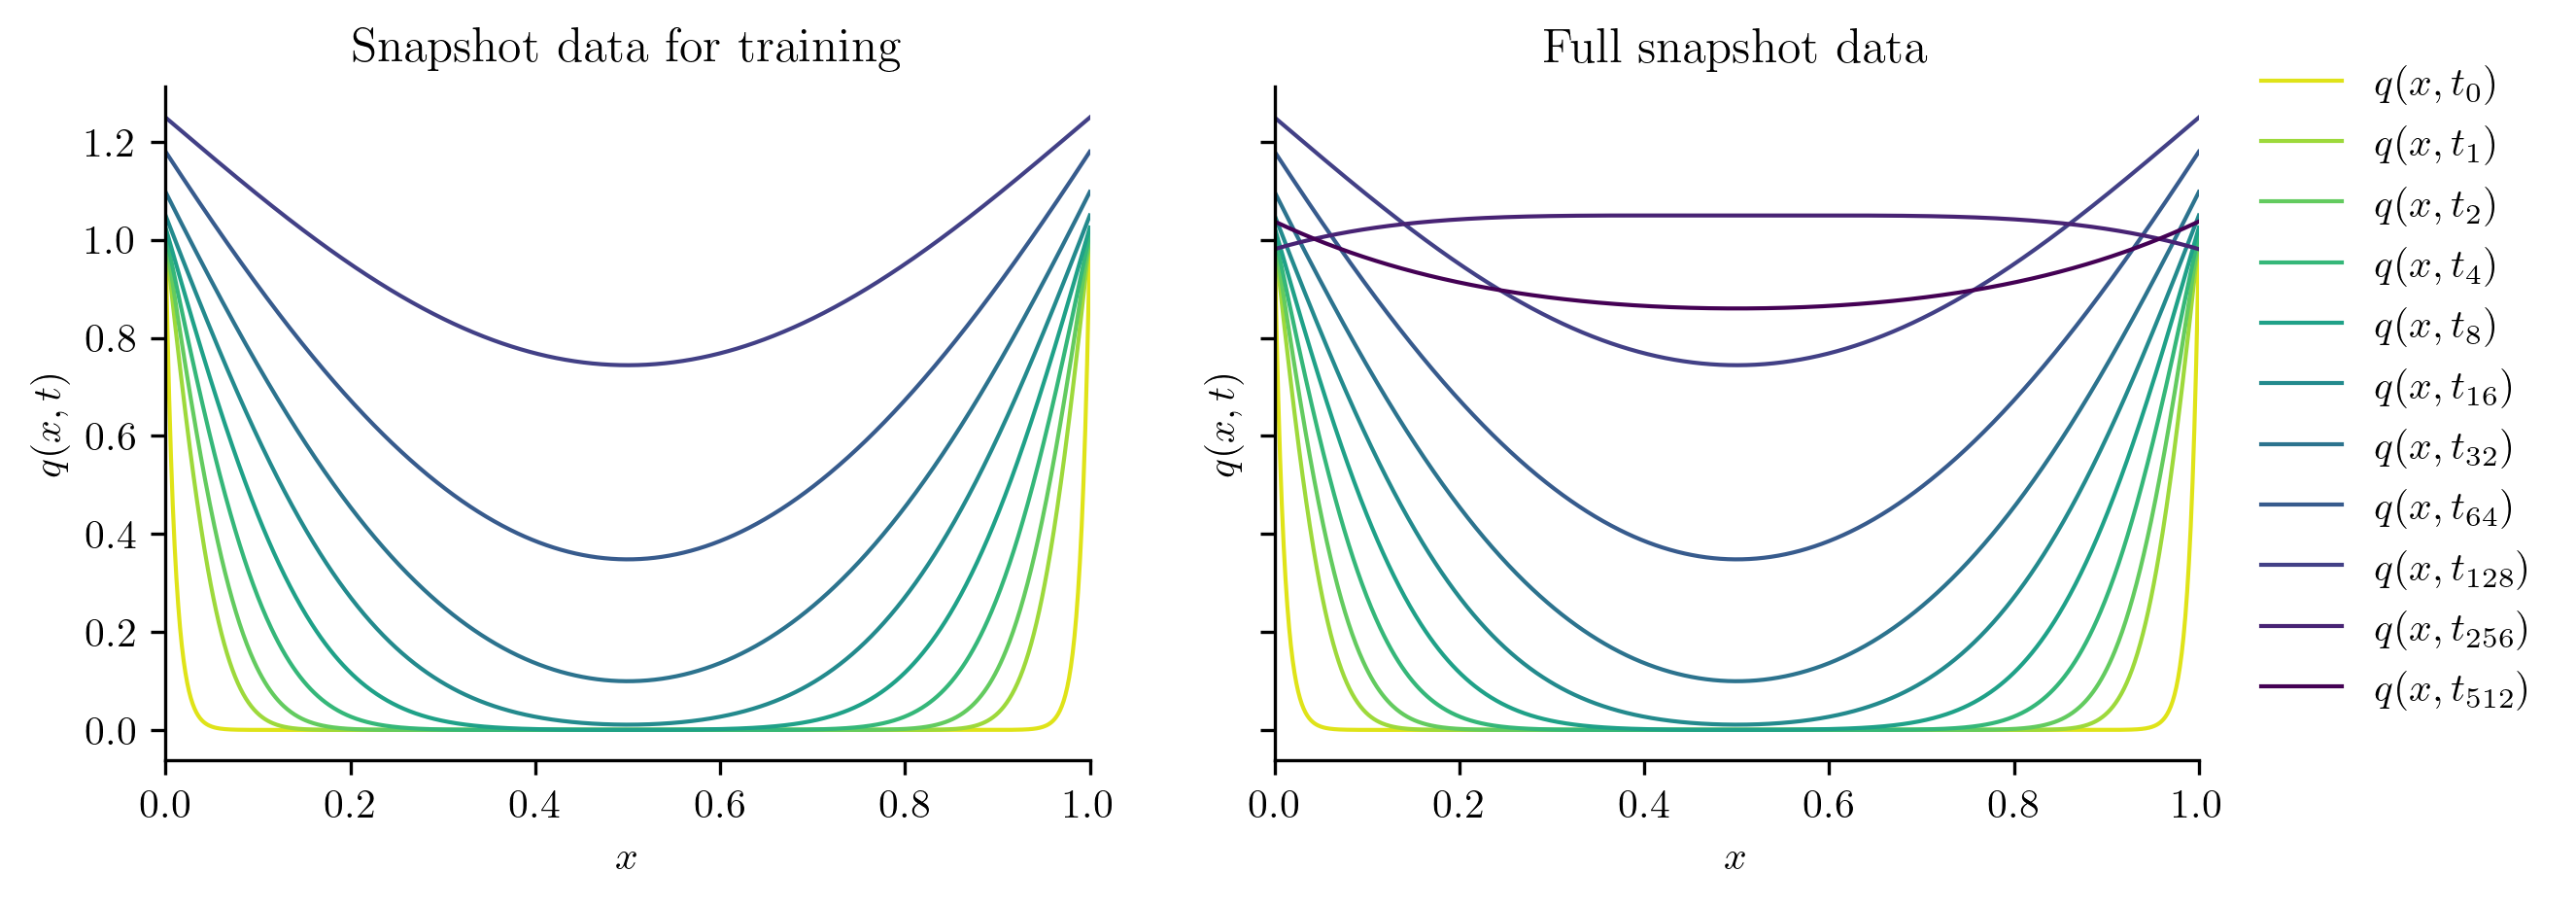

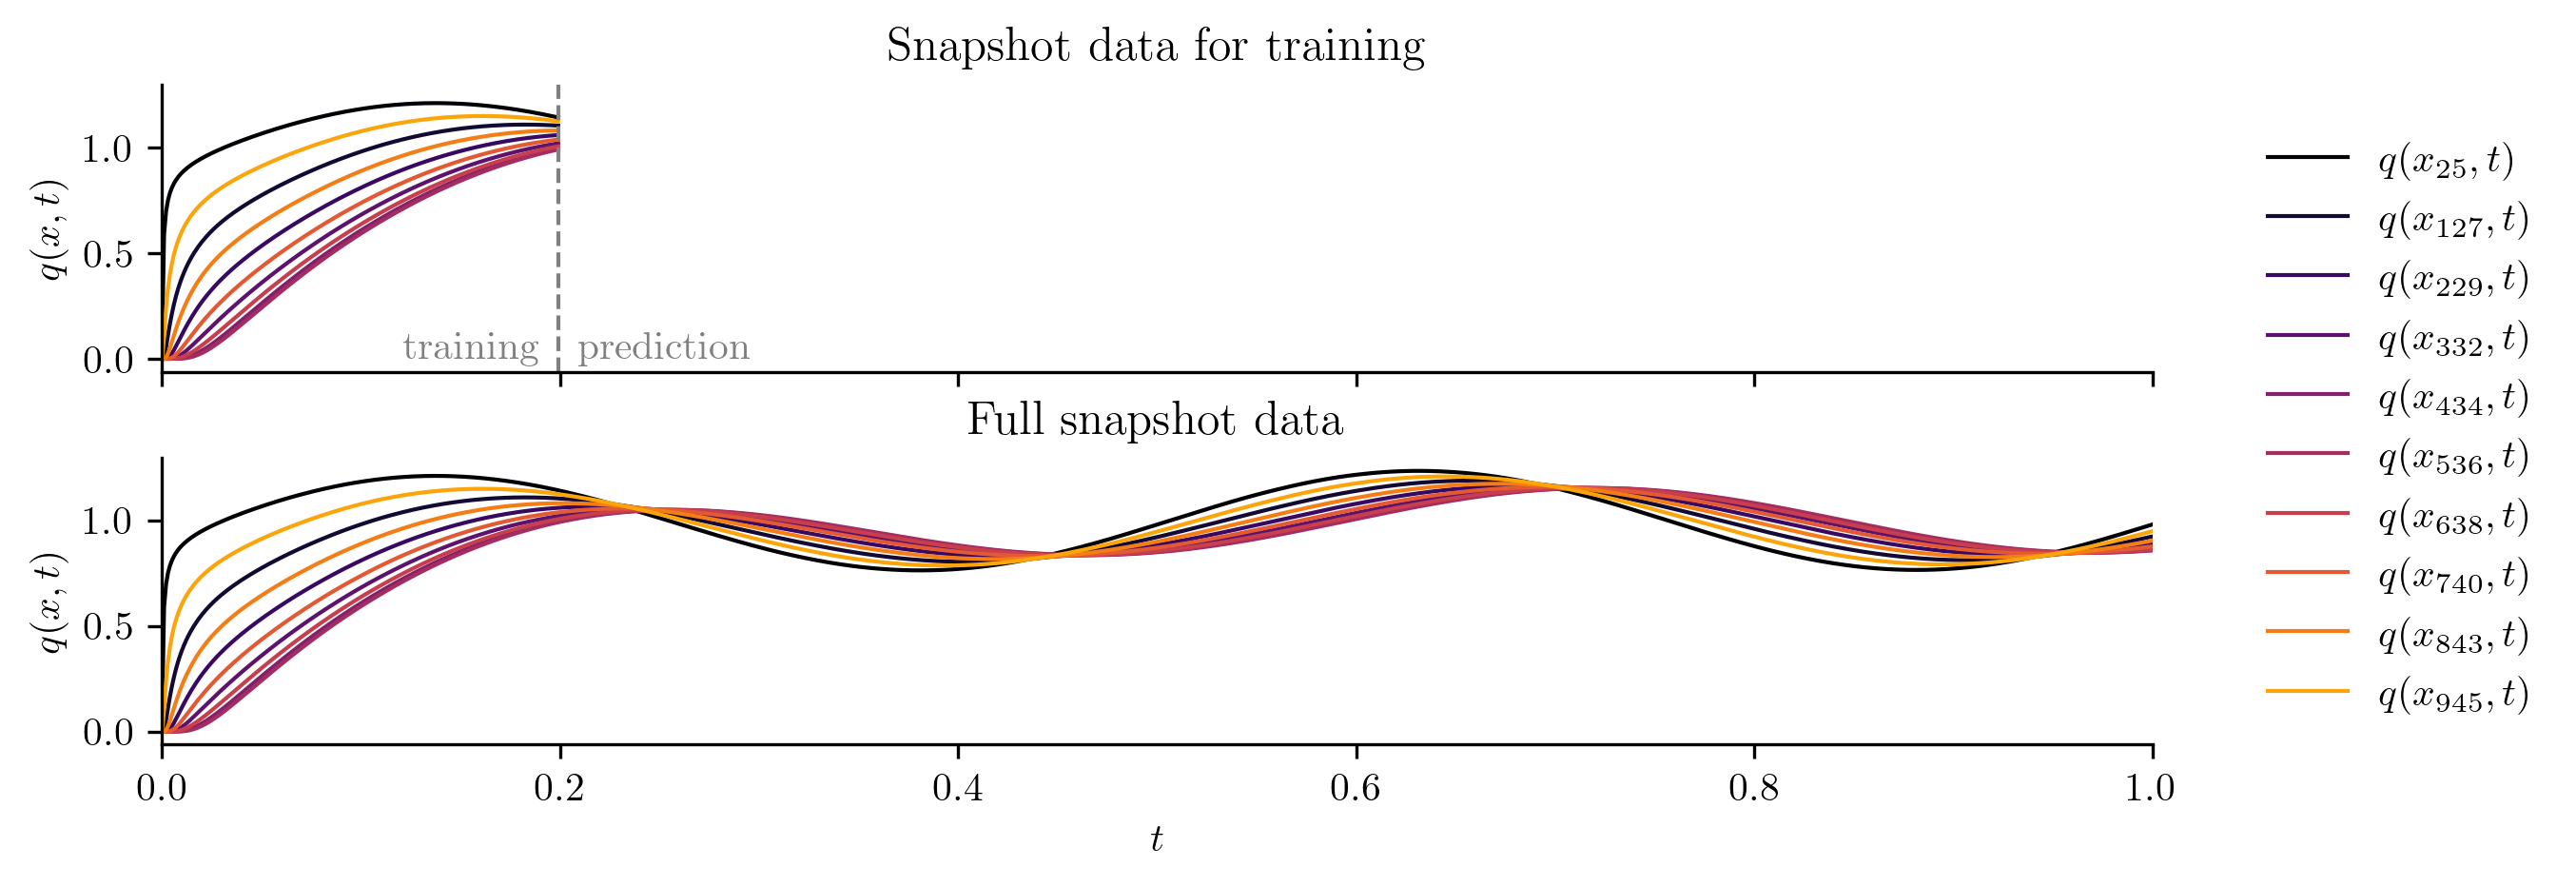

In [6]:
plot_two_datasets(
    Q,
    Q_all,
    U_all,
    "Snapshot data for training",
    "Full snapshot data",
    cutoff=t[-1],
)

### ROM Construction

We will use a {class}`opinf.basis.PODBasis` to reduce the dimension of the snapshot training data, which approximates the discretized state vector as $\q(t) \approx \Vr\qhat(t)$ for some $\Vr\in\RR^{n\times r}$ with orthonormal columns and $\qhat(t)\in\RR^{r}$, with and $r\ll n$.
Input training data are *not* typically compressed with dimensionality reduction or subjected to other pre-processing routines.
Because the FOM {eq}`eq_inputs_fom` has the linear-time invariant form $\ddt\q(t) = \A\q(t) + \B u(t)$, we seek a ROM with the same structure, i.e.,

$$
\begin{aligned}
    \ddt\qhat(t) = \Ahat\qhat(t) + \Bhat u(t),
    \qquad
    \qhat(0) = \Vr\trp\q_0.
\end{aligned}
$$

Data for the time derivative $\ddt\qhat(t)$ are estimated in this example with sixth-order finite differences using {class}`opinf.ddt.UniformFiniteDifferencer`.
The underlying least-squares problem to determine $\Ahat$ and $\Bhat$ is given by

$$
\begin{aligned}
    \min_{\Ahat,\Bhat}
    \sum_{j=0}^{k-1}\left\|
        \Ahat\qhat_{j} + \Bhat\u_j - \dot{\qhat}_j
    \right\|_{2}^{2},
\end{aligned}
$$

where $\qhat_j = \qhat(t_j)\in\RR^{r}$ and $u_j = u(t_j)\in\RR$ are the state snapshots and input data, respectively, and $\dot{\qhat}_j \approx \ddt\qhat(t)|_{t=t_j}\in\RR^{r}$ are the estimated time derivatives.

:::{dropdown} Why Use the Same Structure?

An OpInf ROM should have the same structure as an intrusive Galerkin ROM.
The Galerkin ROM for {eq}`eq_inputs_fom` is derived by substituting in the approximation $\q(t)\approx\Vr\qhat(t)$, yielding

$$
\begin{aligned}
    \ddt\Vr\qhat(t) = \A\Vr\qhat(t) + \B u(t),
    \qquad
    \Vr\qhat(0) = \q_0.
\end{aligned}
$$

Next, left multiply by $\Vr\trp$ and use the fact that $\Vr\trp\Vr = \I$ to get the following:

$$
\begin{aligned}
    \ddt\qhat(t) = \tilde{\A}\qhat(t) + \tilde{\B}u(t),
    \qquad
    \qhat(0) = \Vr\trp\q_0,
\end{aligned}
$$

where $\tilde{\A} = \Vr\trp\A\Vr \in \RR^{r\times r}$ and $\tilde{\B} = \Vr\trp\B\in\RR^{r}$.
Note that this ROM has the same input function $u(t)$ as the FOM.
:::

Training input data are passed to {meth}`opinf.roms.ROM.fit()` as the `inputs` argument.

In [7]:
rom = opinf.ROM(
    basis=opinf.basis.PODBasis(residual_energy=1e-6),
    ddt_estimator=opinf.ddt.UniformFiniteDifferencer(t, "ord6"),
    model=opinf.models.ContinuousModel("AB"),
)

with opinf.utils.TimedBlock("Fitting OpInf ROM"):
    rom.fit(Q, inputs=U)

with opinf.utils.TimedBlock("Reduced-order solve"):
    Q_ROM = rom.predict(q0, t_all, input_func=U_all, method="BDF")

Fitting OpInf ROM...done in 0.41 s.
Reduced-order solve...done in 0.34 s.


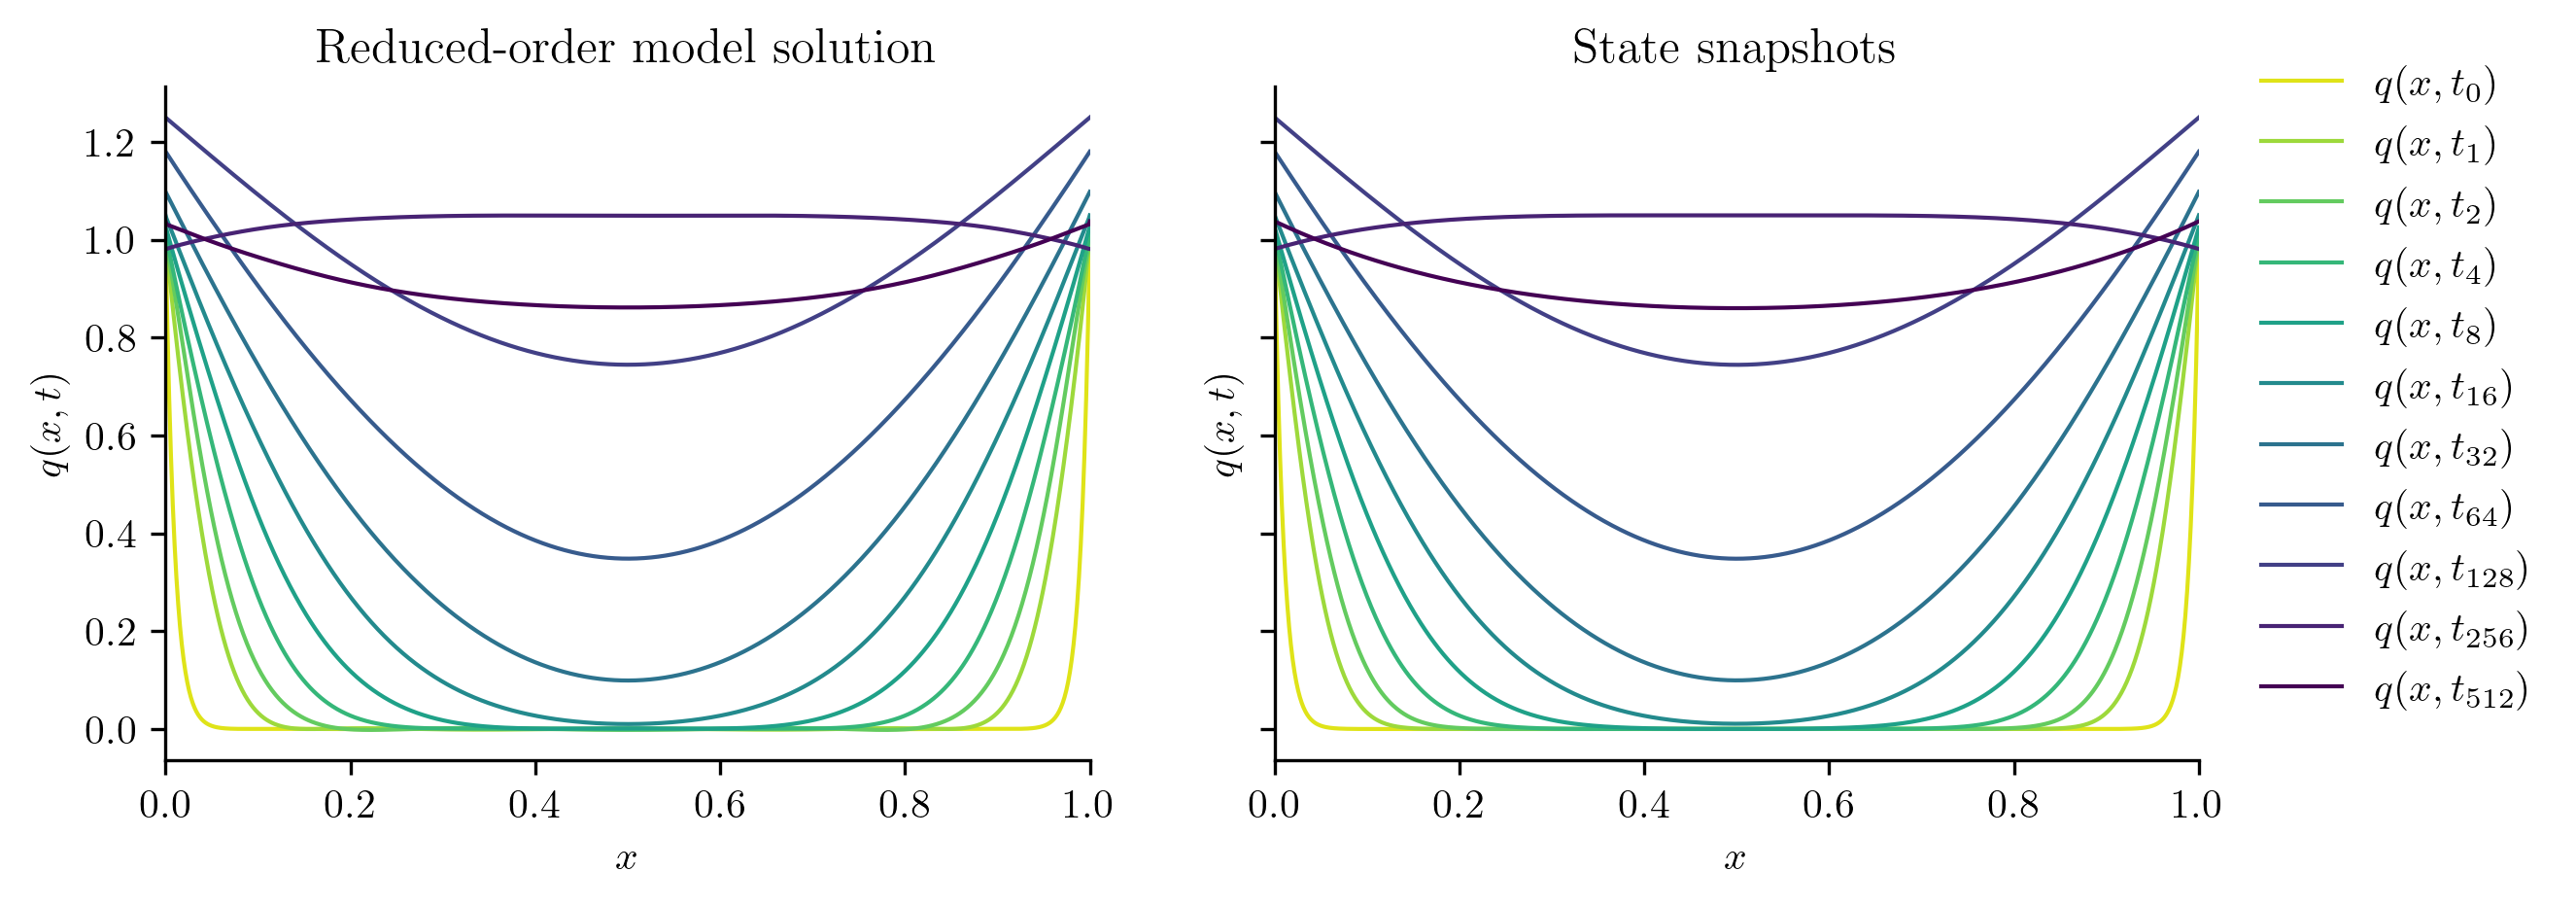

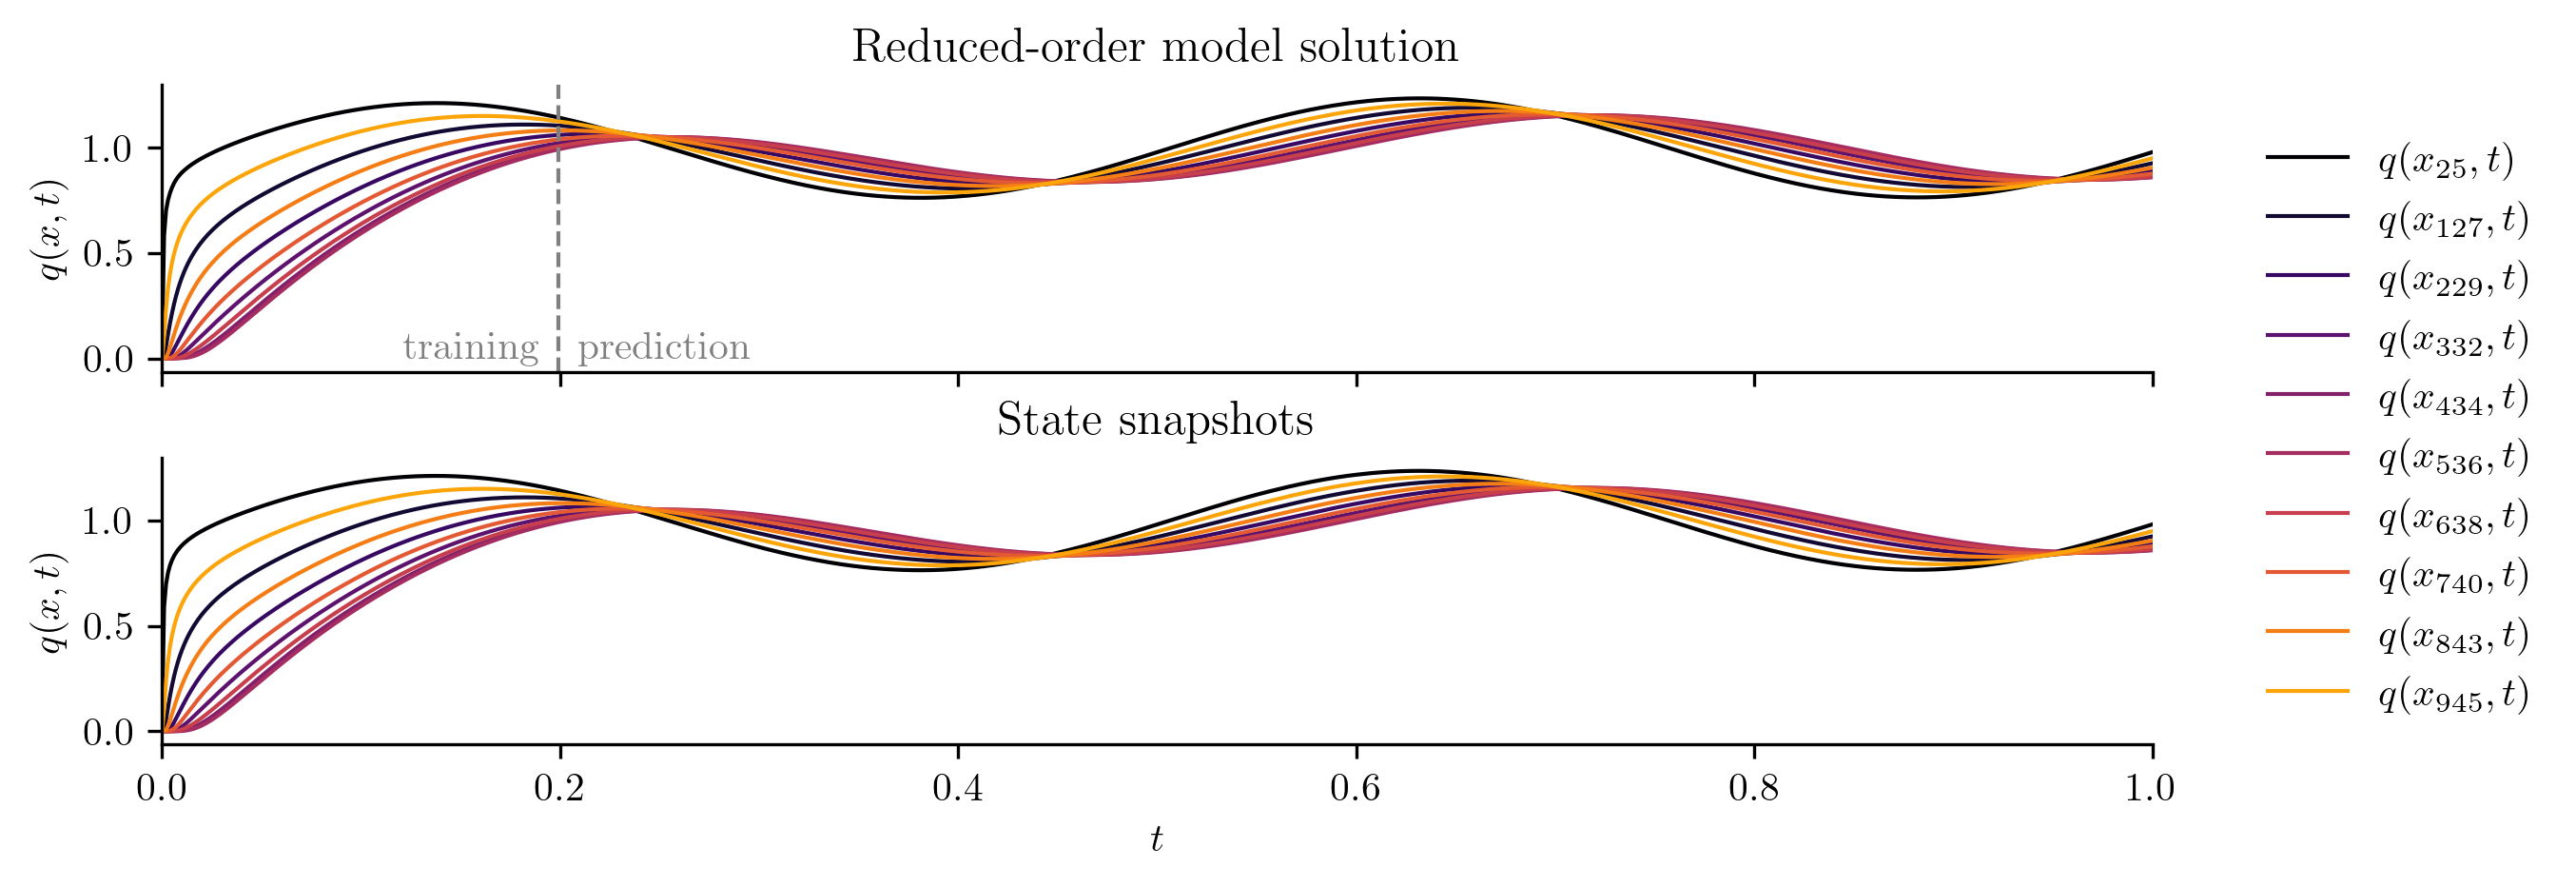

In [7]:
plot_two_datasets(
    Q_ROM,
    Q_all,
    U_all,
    "Reduced-order model solution",
    "State snapshots",
    cutoff=t[-1],
)

For a closer look at the difference between the ROM solutions and the state snapshots, we compute the relative $\ell_2$-norm error of the ROM solution as a function of time using {func}`opinf.post.lp_error()` and the relative Forbenius-norm error using {func}`opinf.post.frobenius_error()`.

In [8]:
def plot_errors_over_time(
    Ztrue, basis, Z1, label1, Z2=None, label2=None, cutoff=None
):
    """Plot normalized absolute projection error and ROM error(s)
    as a function of time.
    """
    _, ax = plt.subplots(1, 1)

    projection_err = opinf.post.lp_error(Ztrue, basis.project(Ztrue))[1]
    ax.semilogy(t_all, projection_err, "C3-", lw=1, label="Projection Error")

    relative_error = opinf.post.lp_error(Ztrue, Z1)[1]
    ax.semilogy(t_all, relative_error, "C0--", lw=1, label=label1)

    if Z2 is not None:
        relative_error = opinf.post.lp_error(Ztrue, Z2)[1]
        ax.semilogy(t_all, relative_error, "C5-.", lw=1, label=label2)

    if cutoff is not None:
        ax.axvline(cutoff, color="gray", linewidth=1, linestyle="--")
        ymin = projection_err.min() / 4
        ax.text(cutoff - 10 * dt, ymin, "training", ha="right", color="gray")
        ax.text(cutoff + 10 * dt, ymin, "prediction", ha="left", color="gray")
        ax.set_ylim(bottom=ymin / 2)

    ax.set_xlim(t_all[0], t_all[-1])
    ax.set_xlabel(r"$t$")
    ax.set_ylabel("Relative error")
    ax.legend(loc="lower right")
    plt.show()

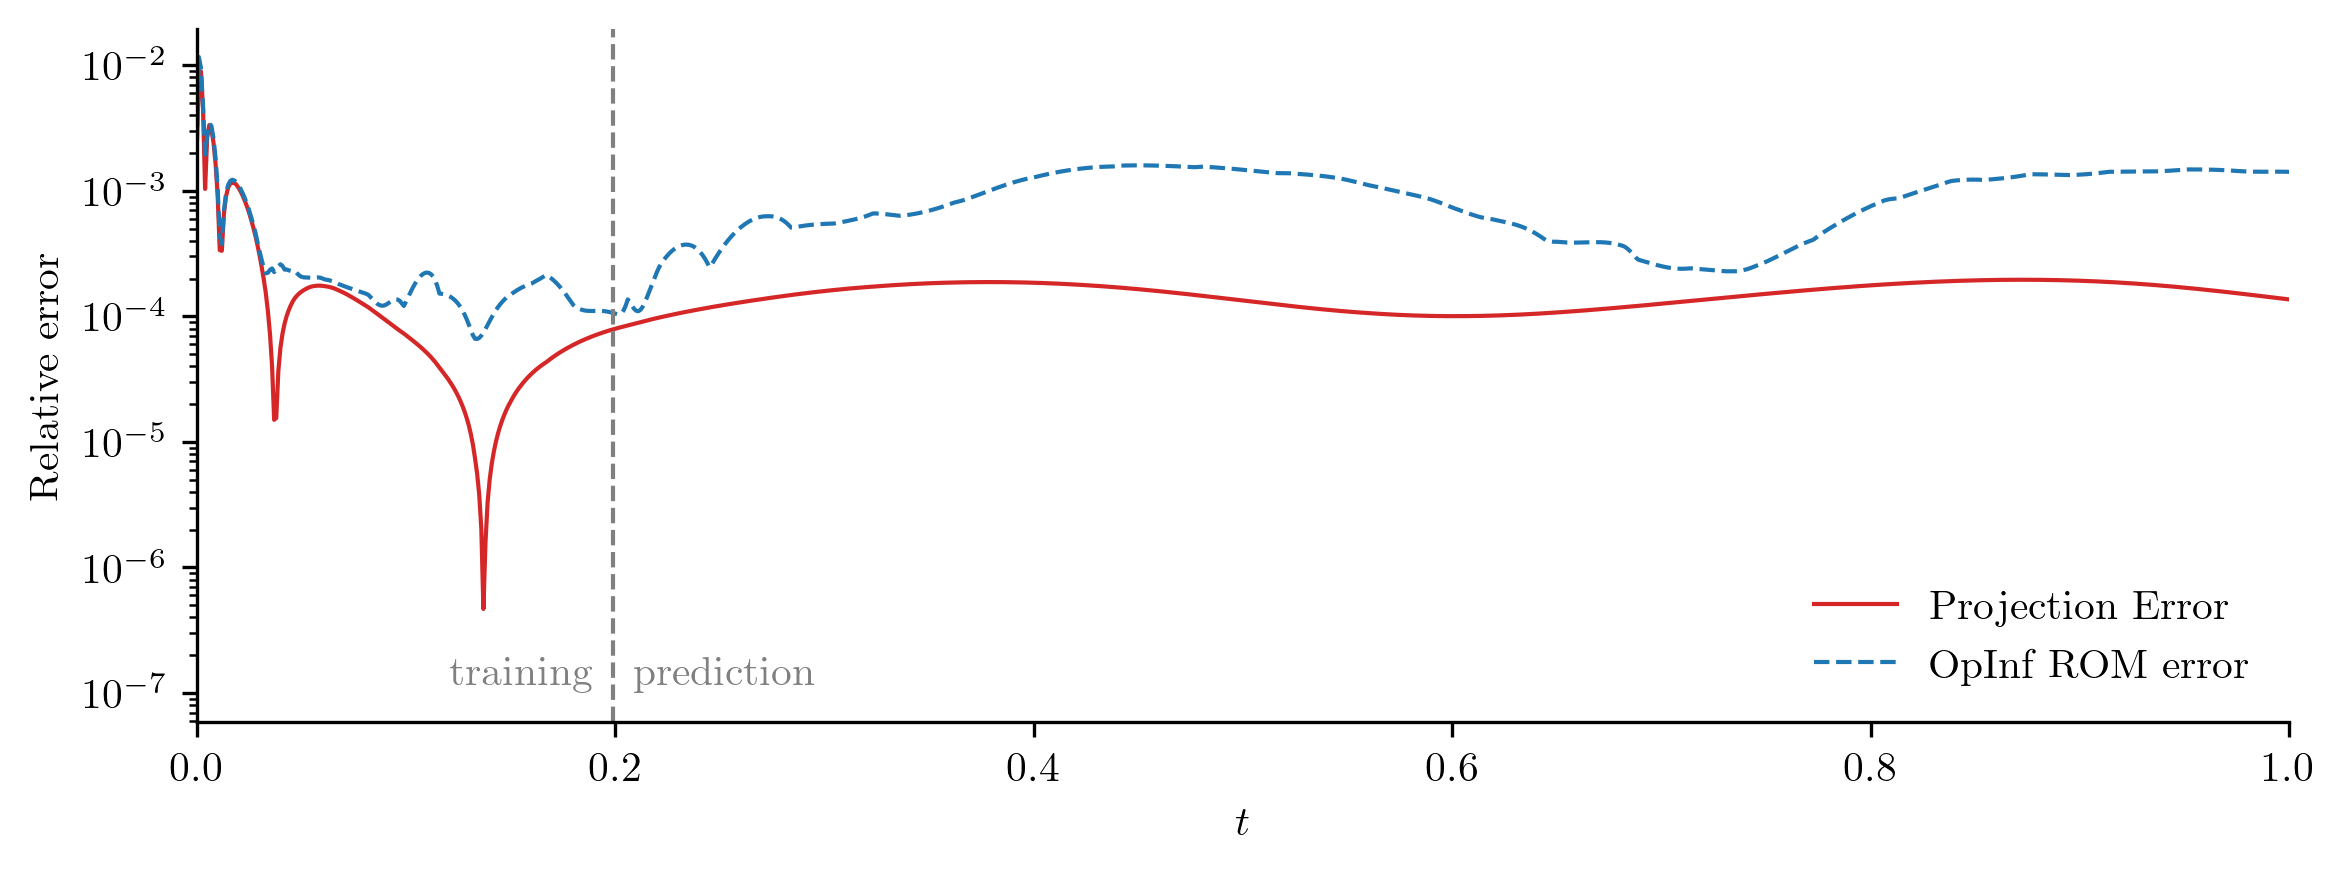

In [10]:
plot_errors_over_time(Q_all, rom.basis, Q_ROM, "OpInf ROM error", cutoff=t[-1])

In [11]:
error_opinf = opinf.post.frobenius_error(Q_all, Q_ROM)[1]
print(f"OpInf ROM error:\t{error_opinf:.4e}")

OpInf ROM error:	8.8303e-04


### Comparison to the Intrusive Galerkin ROM

The classical intrusive Galerkin ROM for this problem is given by

$$
\begin{aligned}
    \ddt\qhat(t) = \tilde{\A}\qhat(t) + \tilde{\B}u(t),
    \qquad
    \qhat(0) = \Vr\trp\q_0,
\end{aligned}
$$

where $\tilde{\A} = \Vr\trp\A\Vr \in \RR^{r\times r}$ and $\tilde{\B} = \Vr\trp\B\in\RR^{r}$.
Here, we form this ROM explicitly (using the same basis matrix $\Vr$ as before) and compare it to our existing OpInf ROM.

In [26]:
def test_input(t):
    return 1 + t * (1 - t)

# Construct the spatial domain.
L = 1
n = 2**10 - 1
x_all = np.linspace(0, L, n + 2)
x = x_all[1:-1]
dx = x[1] - x[0]

# Construct the temporal domain.
T = 1
K = 10**3 + 1
t_all = np.linspace(0, T, K)
dt = t_all[1] - t_all[0]

# Construct the full-order state matrix A.
dx2inv = 1 / dx**2
diags = np.array([1, -2, 1]) * dx2inv
A = scipy.sparse.diags(diags, [-1, 0, 1], (n, n))

# Construct the full-order input matrix B.
B = np.zeros_like(x)
B[0], B[-1] = dx2inv, dx2inv

# Define the full-order model with an opinf.models class.
fom = opinf.models.ContinuousModel(
    operators=[
        opinf.operators.LinearOperator(A),
        opinf.operators.InputOperator(B),
    ]
)

# Construct the part of the initial condition not dependent on u(t).
alpha = 100
q0 = np.exp(alpha * (x - 1)) + np.exp(-alpha * x) - np.exp(-alpha)


def full_order_solve(time_domain, u):
    """Solve the full-order model with SciPy.
    Here, u is a callable function.
    """
    return fom.predict(q0 * u(0), time_domain, u, method="BDF")

In [27]:
rom_intrusive = opinf.ROM(
    basis=rom.basis,
    model=fom.galerkin(rom.basis.entries),  # Explicitly project FOM operators.
)

In [28]:
with opinf.utils.TimedBlock("Reduced-order model solve (intrusive)"):
    Q_ROM_intrusive = rom_intrusive.predict(
        q0, t_all, input_func=U_all, method="BDF"
    )

Reduced-order model solve (intrusive)...done in 0.22 s.


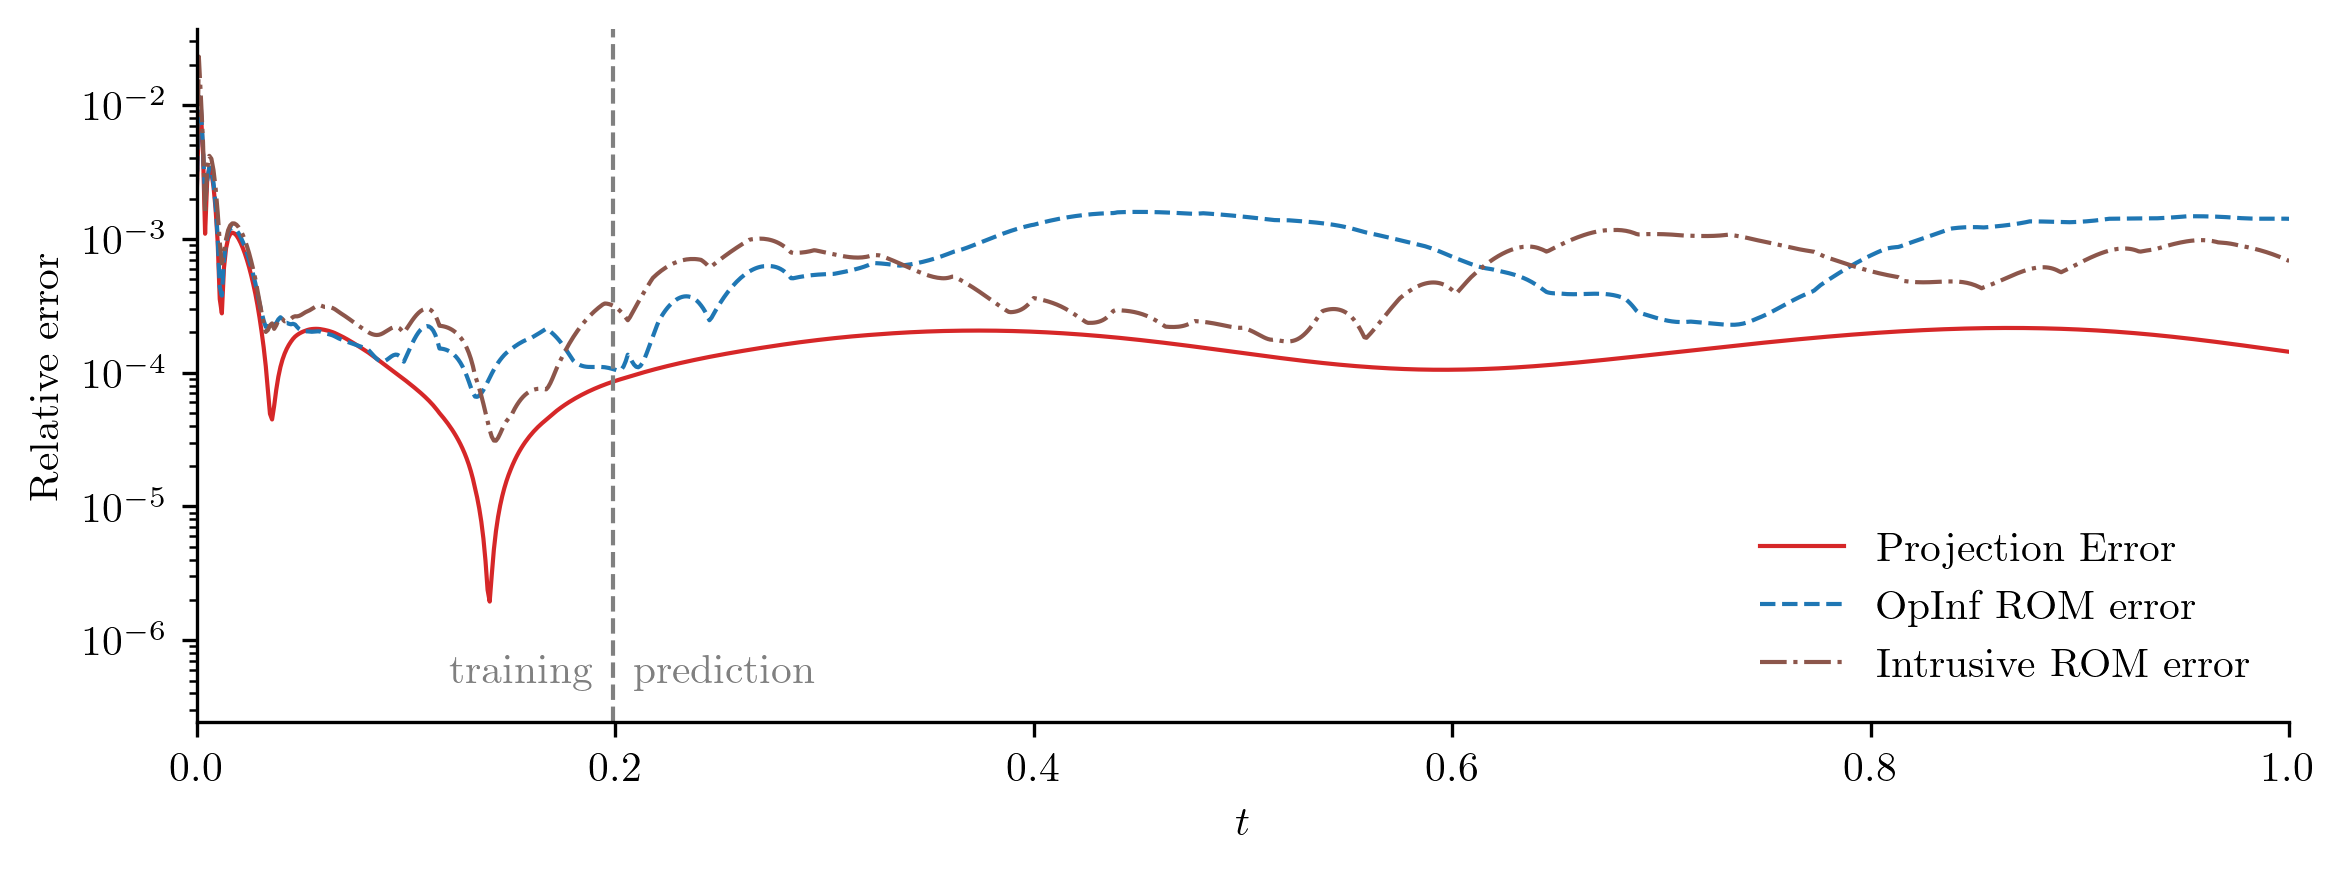

In [29]:
plot_errors_over_time(
    Q_all,
    rom.basis,
    Q_ROM,
    "OpInf ROM error",
    Q_ROM_intrusive,
    "Intrusive ROM error",
    cutoff=t[-1],
)

In [30]:
error_intrusive = opinf.post.frobenius_error(Q_all, Q_ROM_intrusive)[1]
error_projection = rom.basis.projection_error(Q_all, relative=True)

print(
    "Relative Frobenius-norm errors",
    "-" * 33,
    f"Projection error:\t{error_projection:%}",
    f"OpInf ROM error:\t{error_opinf:%}",
    f"Intrusive ROM error:\t{error_intrusive:%}",
    sep="\n",
)

Relative Frobenius-norm errors
---------------------------------
Projection error:	0.020145%
OpInf ROM error:	0.088303%
Intrusive ROM error:	0.070156%


In this experiment, the OpInf ROM and the corresponding intrusive ROM have comparable error, even though the OpInf ROM is calibrated without intrusive access to the FOM.

### Generalization to New Inputs

The previous experiment uses a single choice of $u(t)$ for the training and for the prediction in time.
Now, we define a new choice of input function $u(t)$,

$$
\begin{aligned}
    u_\text{test}(t)
    = 1 + t(1 - t),
\end{aligned}
$$

and evaluate the ROM for this new input.

In [31]:
with opinf.utils.TimedBlock("Reduced-order solve (OpInf)"):
    Qtest_ROM = rom.predict(q0, t_all, U_test, method="BDF")

Full-order solve...done in 9.81 s.
Reduced-order solve (OpInf)...done in 0.16 s.
Reduced-order solve (intrusive)...done in 0.24 s.


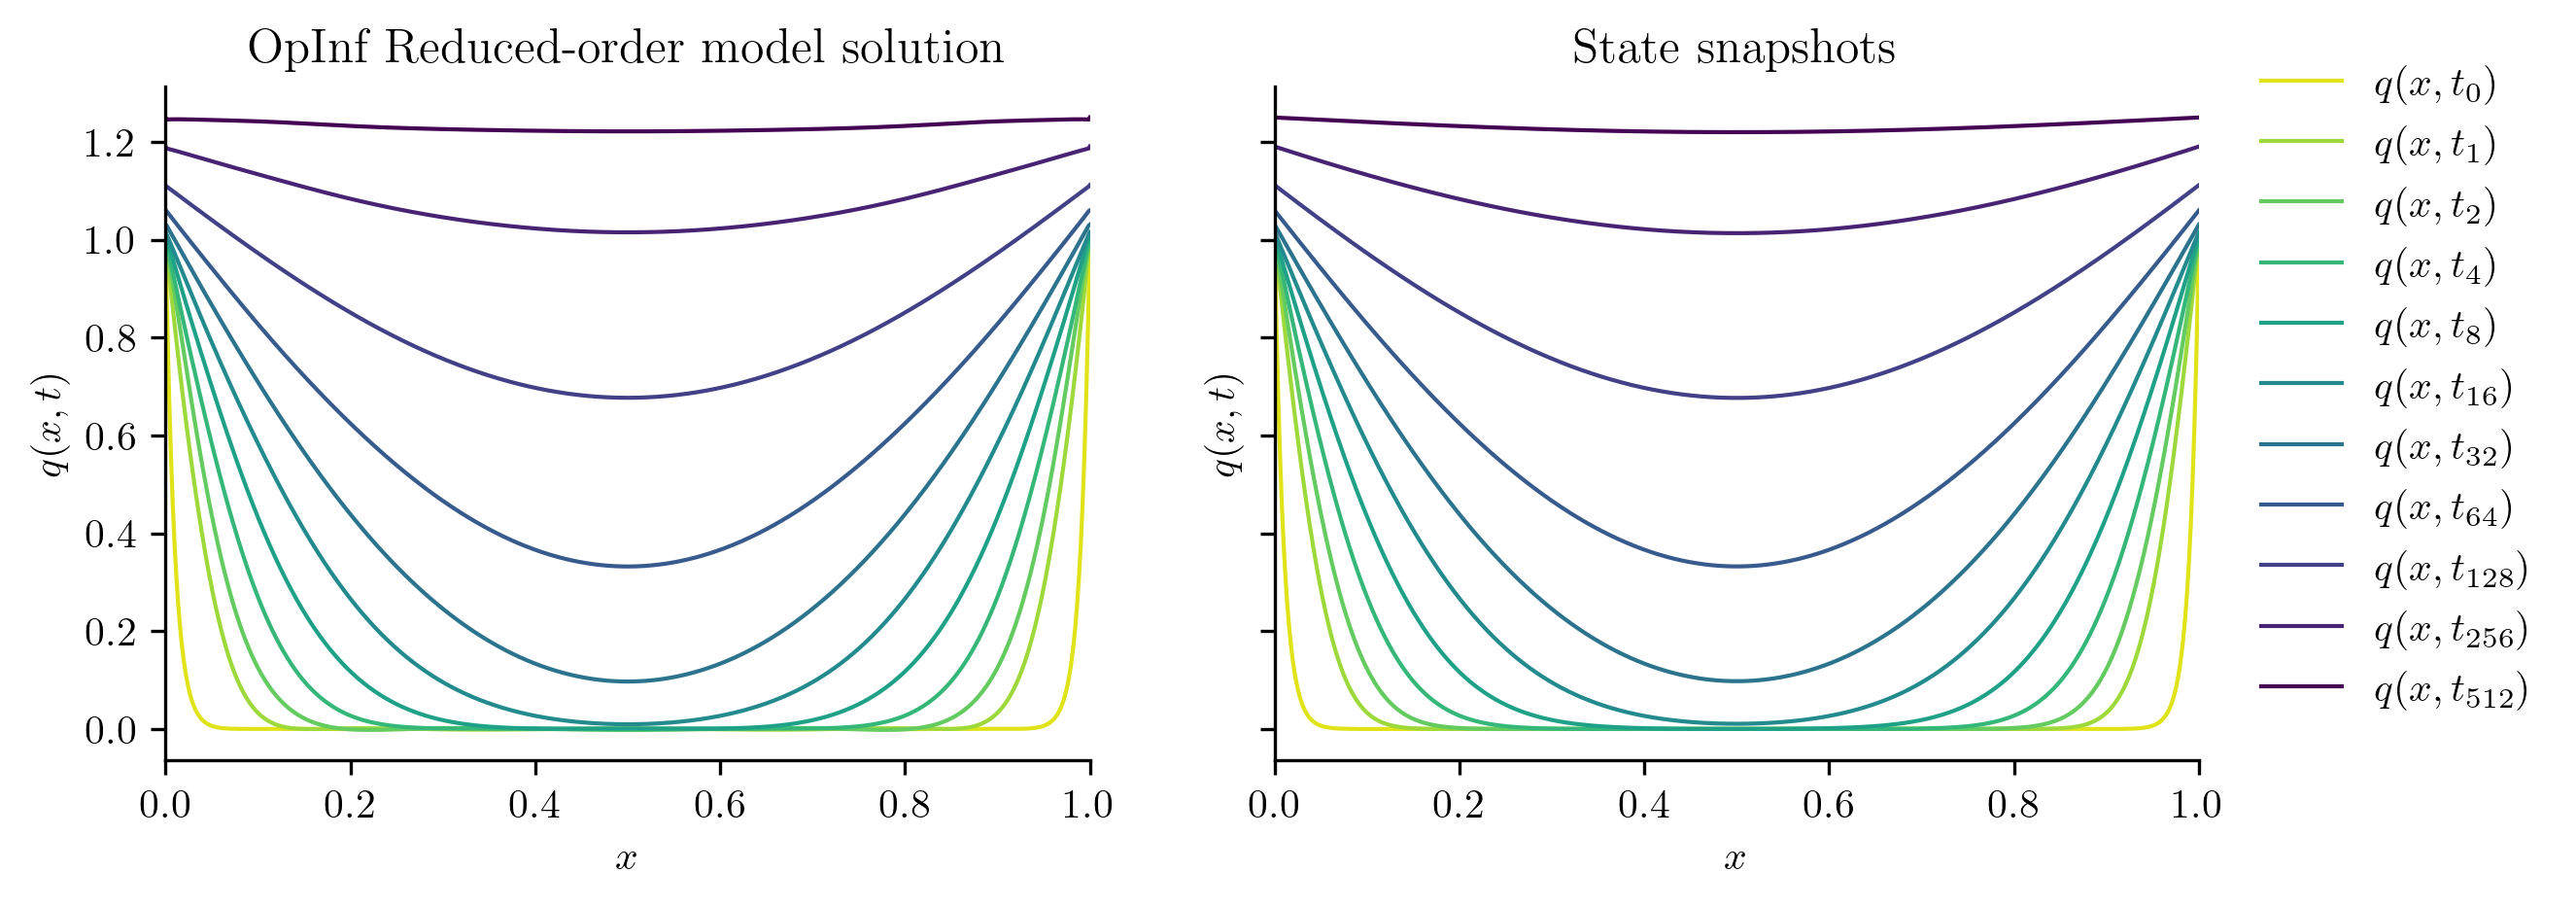

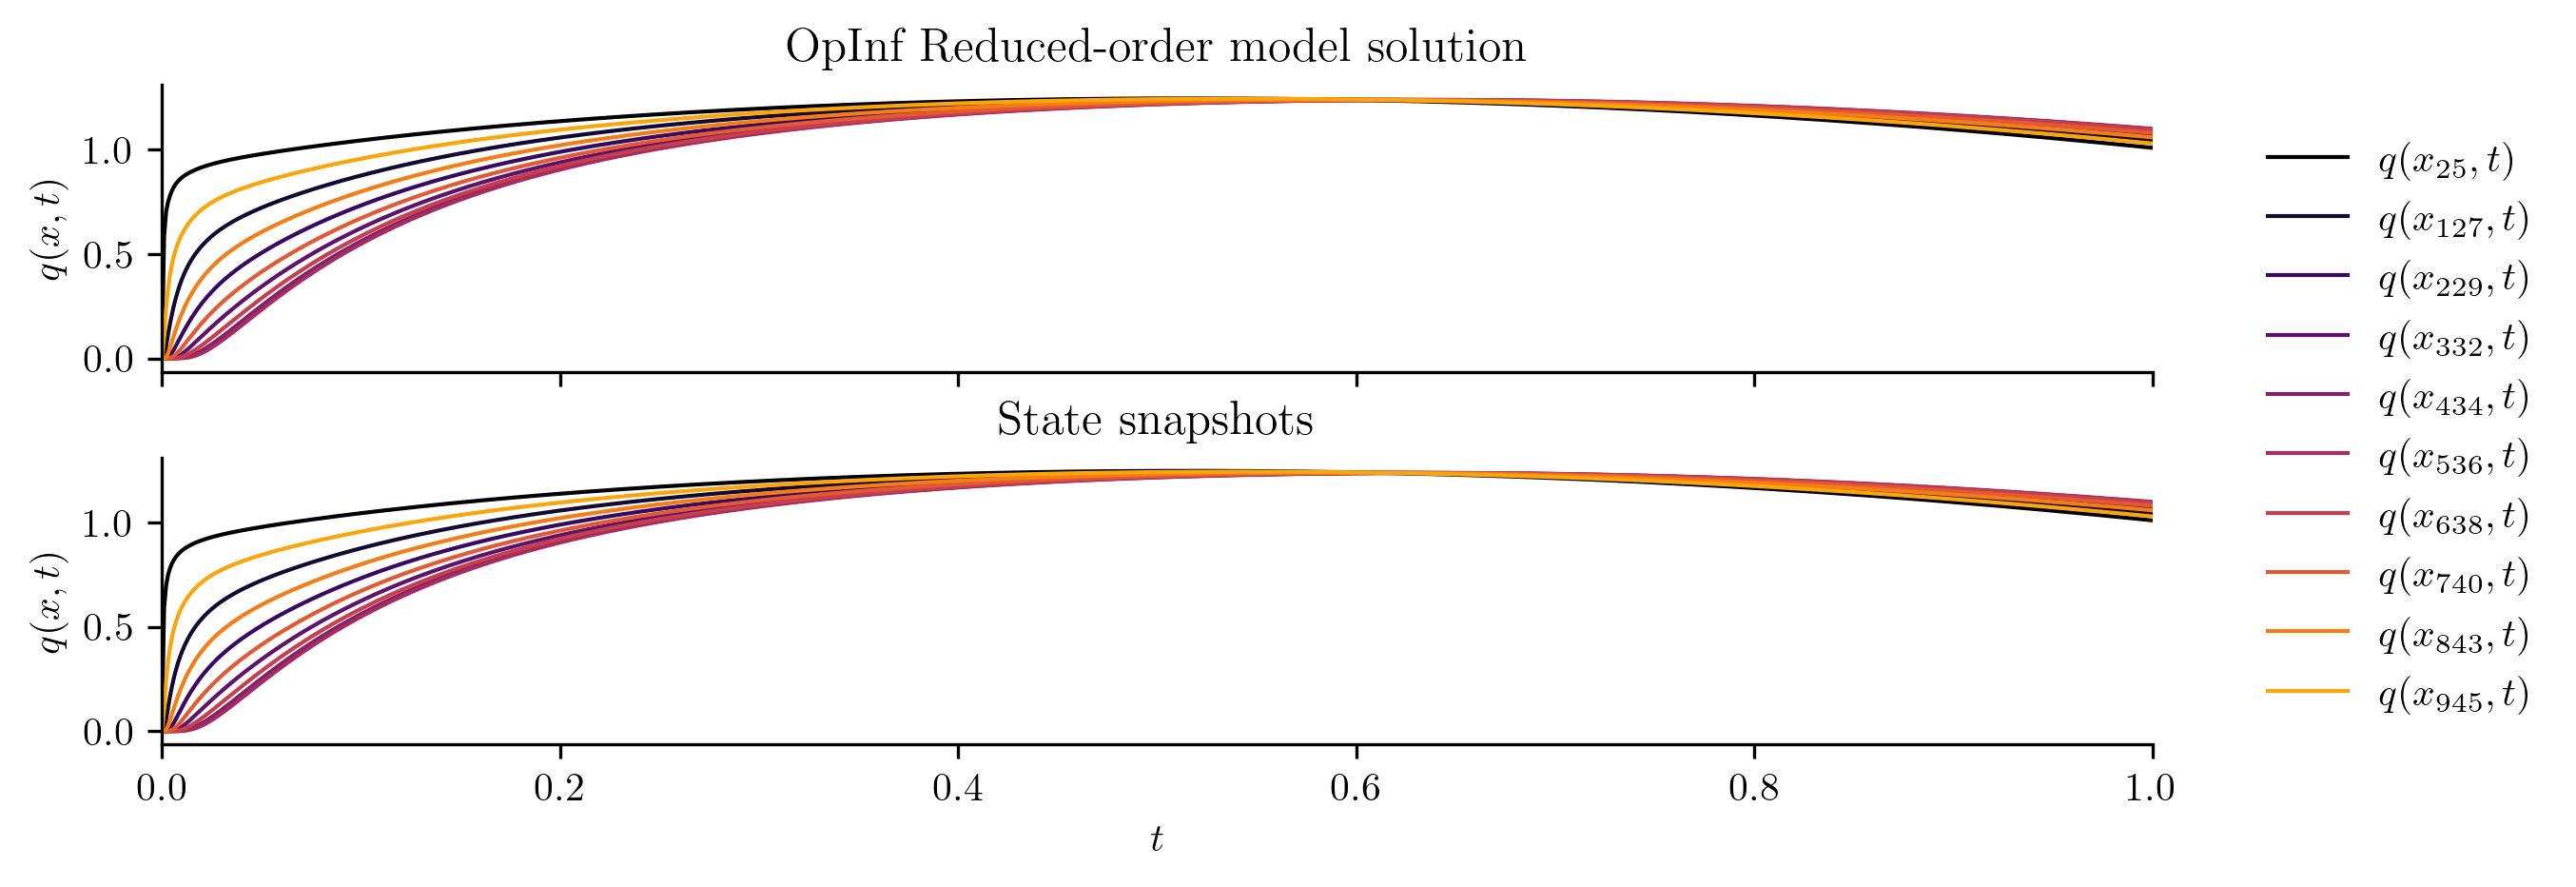

In [13]:
plot_two_datasets(
    Qtest_ROM,
    Q_test,
    U_test,
    "OpInf Reduced-order model solution",
    "State snapshots",
)

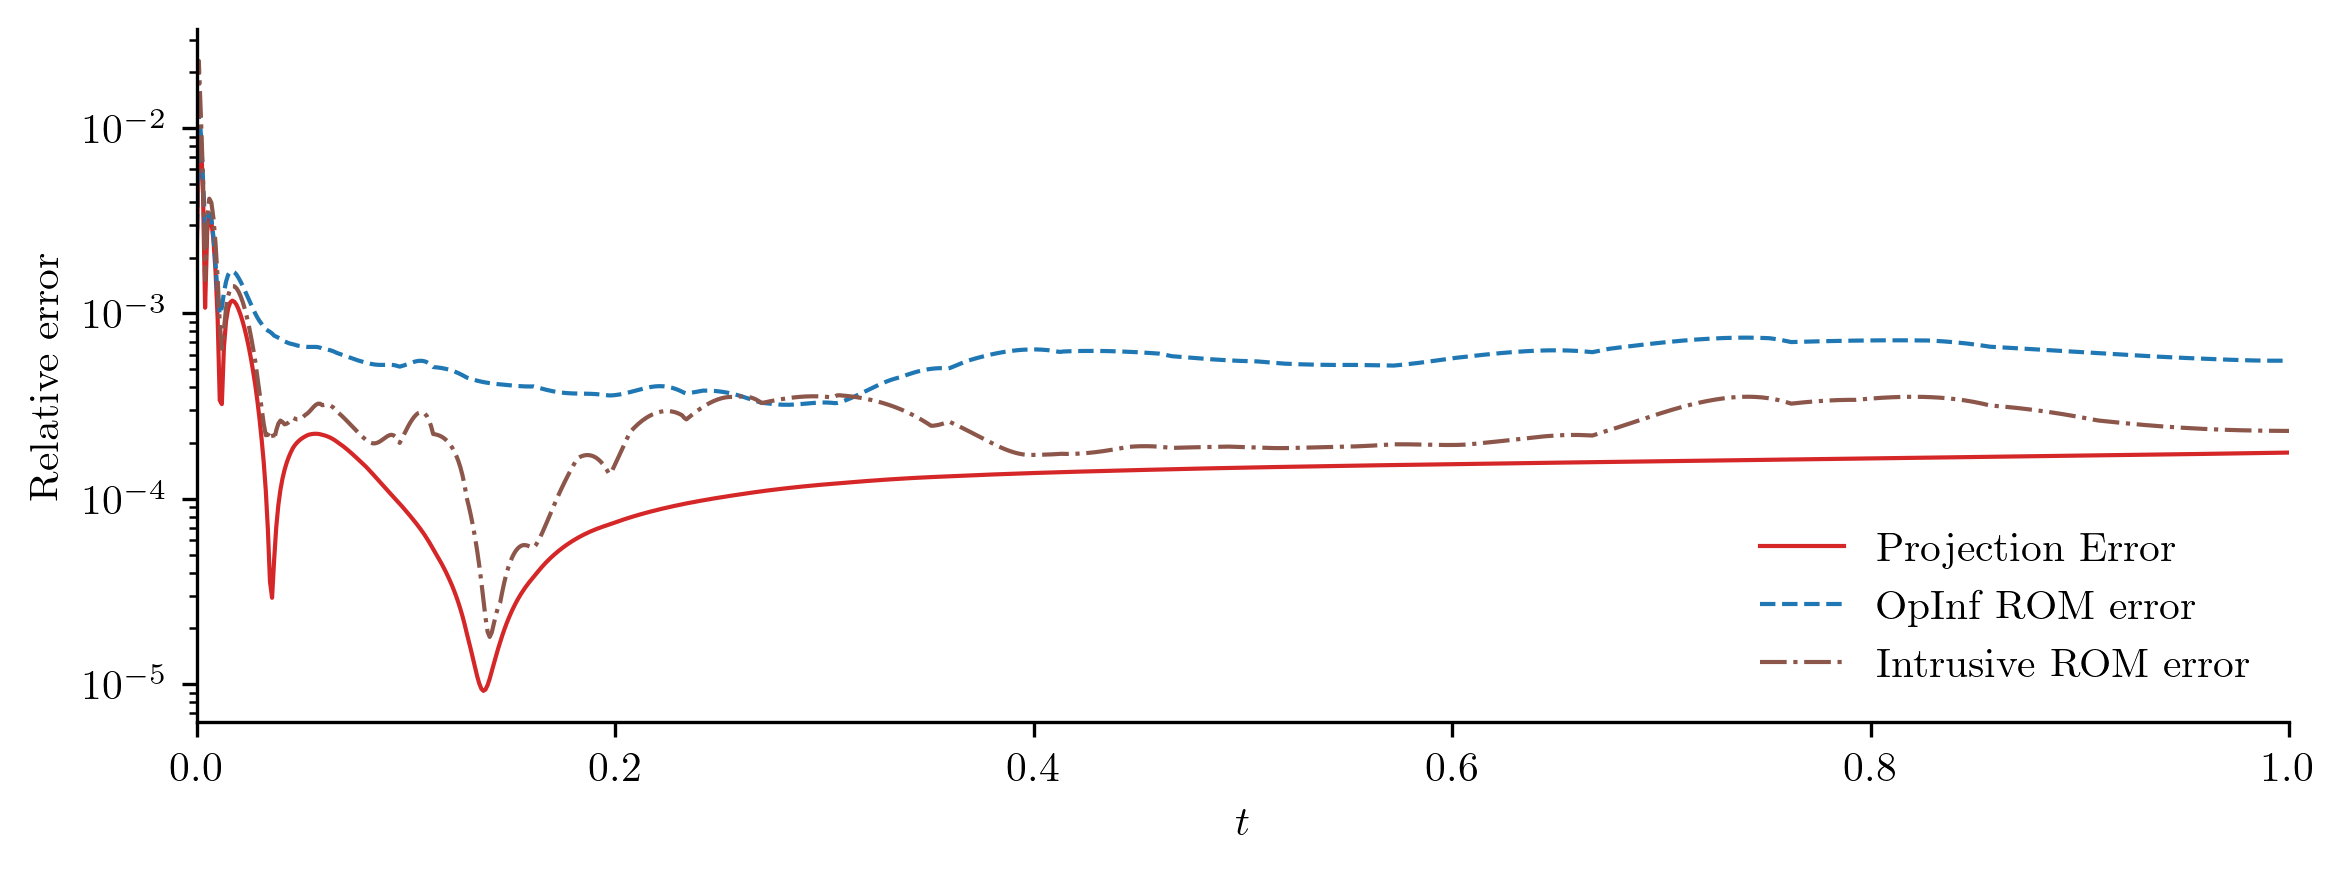

In [35]:
plot_errors_over_time(
    Q_test,
    rom.basis,
    Qtest_ROM,
    "OpInf ROM error",
)

## Multiple Training Trajectories

If data corresponding to several choices of the input function $u(t)$ are available for training, we collect a list of snapshot matrices and a list of corresponding inputs to pass to `fit()`.

### Training Data Generation

Below, we solve use the ROM to simulate the three input functions for training data:

$$
\begin{aligned}
    &u_\text{train}^{(1)}(t) = e^{-t},
    &&&
    &u_\text{train}^{(2)}(t) = 1 + \frac{1}{2}t^2,
    &&&
    &u_\text{train}^{(3)}(t) = 1 - \frac{1}{2}\sin(\pi t).
\end{aligned}
$$

The following input functions are used for testing:

$$
\begin{aligned}
    &u_\text{test}^{(1)}(t) = 1 - \frac{1}{2}\sin(3\pi t),
    &&&
    &u_\text{test}^{(2)}(t) = 1 + 25 (t (t - 1))^3,
    &&&
    &u_\text{test}^{(3)}(t) = 1 + e^{-2t}\sin(\pi t).
\end{aligned}
$$

In [36]:
# Load the generated training data
Qs_train = []  # State snapshots.
Us_train_all = []  # Corresponding inputs.
Us_train = []  # truncated inputs for training the ROM.
Qs_test = []
Us_test = []

with h5py.File(filepath, 'r') as f:
    for idx in range(f["train"].attrs["num_input_functions"]):
        Qs_train.append(f["train"][f"Q_{idx}"][:, :k])
        Us_train_all.append(f["train"][f"U_{idx}"][:])
        Us_train.append(f["train"][f"U_{idx}"][:k])

    for idx in range(f["test"].attrs["num_input_functions"]):
        Qs_test.append(f["test"][f"Q_{idx}"][:])
        Us_test.append(f["test"][f"U_{idx}"][:])

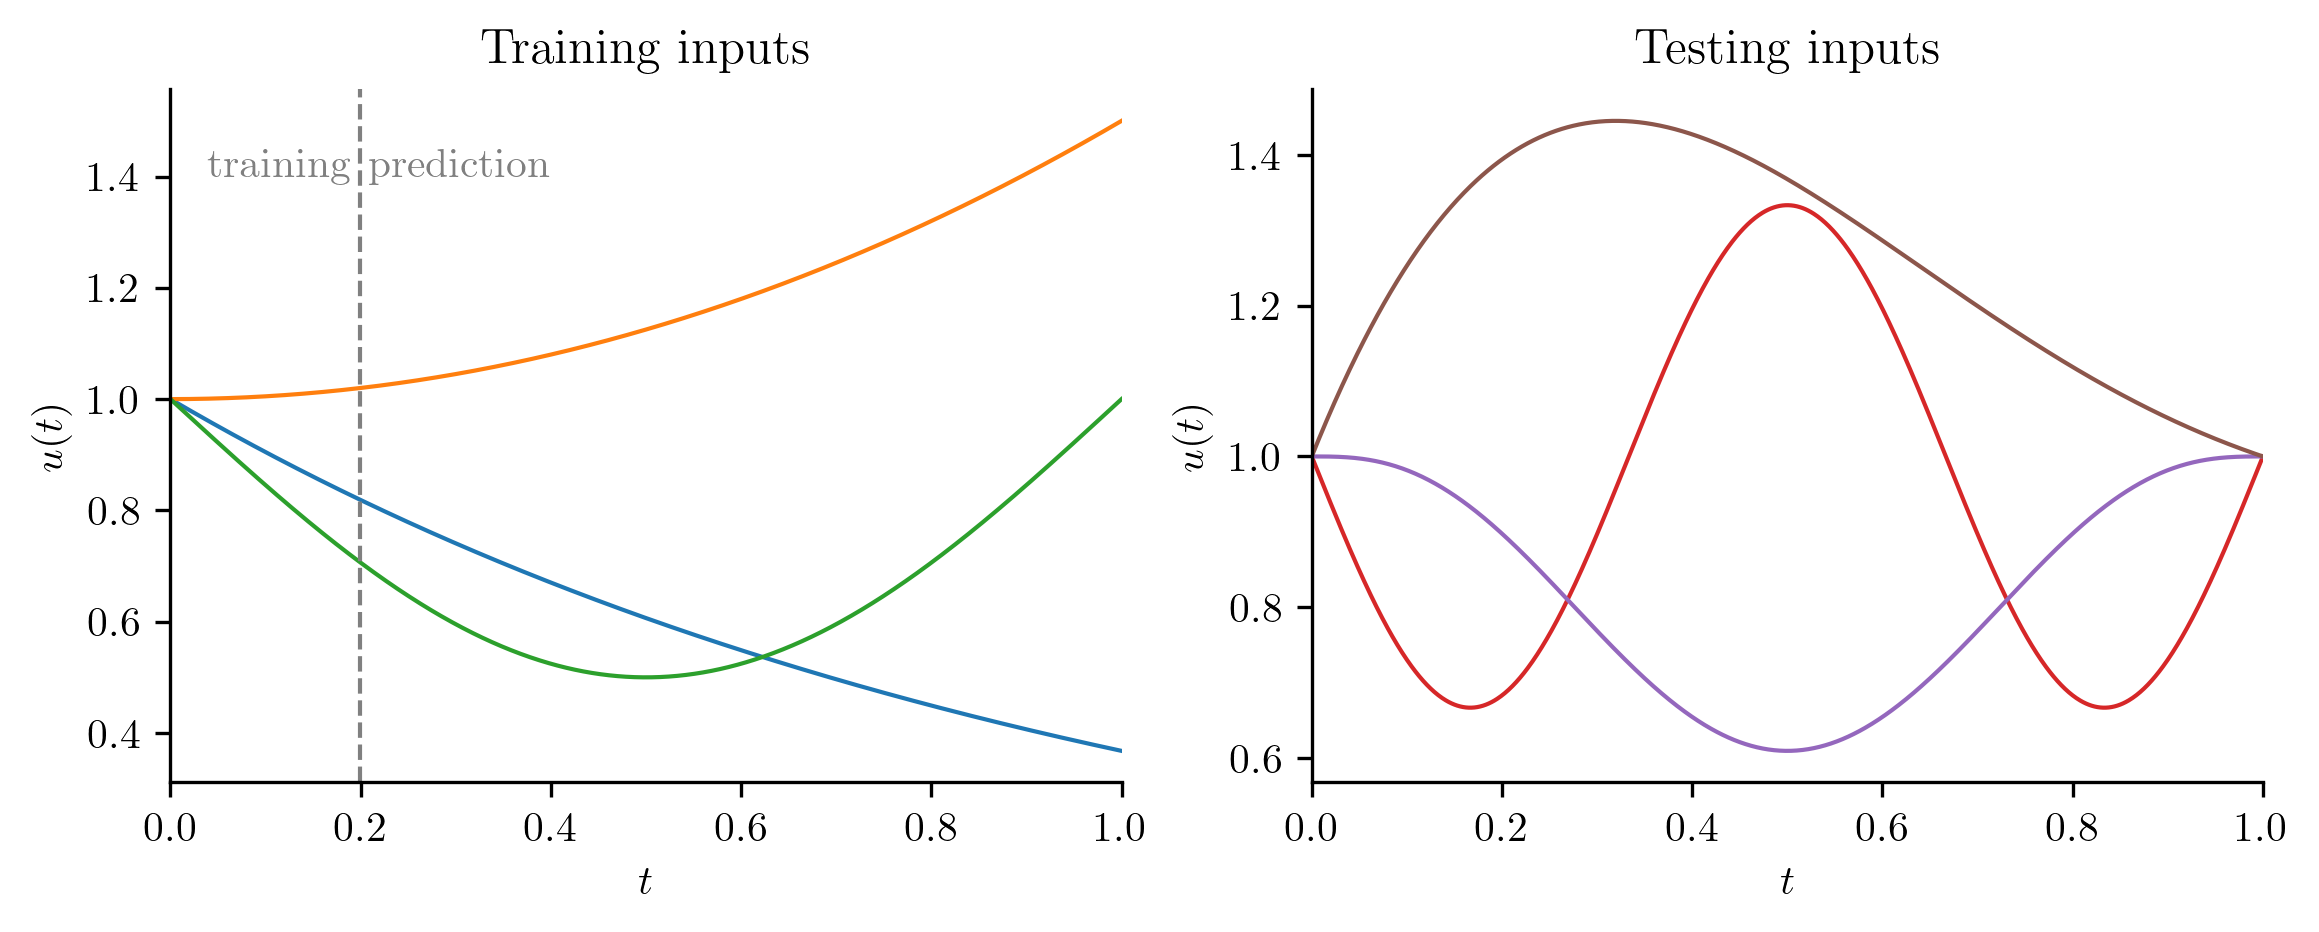

In [37]:
# Visualize the input functions.
fig, [ax1, ax2] = plt.subplots(1, 2, sharex=True)
c = 0
for inputs in Us_train_all:
    ax1.plot(t_all, inputs, color=f"C{c}", lw=1)
    c += 1
for inputs in Us_test:
    ax2.plot(t_all, inputs, color=f"C{c}", lw=1)
    c += 1

ax1.set_title("Training inputs")
ax2.set_title("Testing inputs")
# ax1.axvline(t[-1], color="k", lw=1)
ax1.axvline(t[-1], color="gray", linewidth=1, linestyle="--")
ax1.text(t[-1] - 10 * dt, 1.4, "training", ha="right", color="gray")
ax1.text(t[-1] + 10 * dt, 1.4, "prediction", ha="left", color="gray")
for ax in (ax1, ax2):
    ax.set_xlim(t_all[0], t_all[-1])
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$u(t)$")
plt.show()

In [38]:
rom = opinf.ROM(
    basis=opinf.basis.PODBasis(residual_energy=1e-6),
    ddt_estimator=opinf.ddt.UniformFiniteDifferencer(t, "ord6"),
    model=opinf.models.ContinuousModel("AB"),
)

with opinf.utils.TimedBlock("Fitting OpInf ROM"):
    rom.fit(Qs_train, inputs=Us_train)

rom_intrusive = opinf.ROM(
    basis=rom.basis,
    model=fom.galerkin(rom.basis.entries),
)

Fitting OpInf ROM...done in 4.24 s.


In [ ]:
for i, u in enumerate(Us_test):
    print(f"Test input function {i+1:d}")

    with opinf.utils.TimedBlock("Reduced-order solve (OpInf)"):
        Q_ROM = rom.predict(q0, t_all, U, method="BDF")

    plot_two_datasets(
        Q_ROM,
        Q,
        U,
        "Reduced-order model solution (OpInf)",
        "Full-order model solution",
    )

    plot_errors_over_time(
        Q,
        rom.basis,
        Q_ROM,
        "OpInf ROM error"
    )

Test input function 1
Reduced-order solve (OpInf)...done in 0.19 s.
Reduced-order solve (intrusive)...done in 0.28 s.


IndexError: string index out of range

:::{admonition} Multi-dimensional Inputs
:class: tip

The examples in this tutorial use a scalar-valued input function $u:\RR\to\RR$.
For models with vector inputs $\u:\RR\to\RR^m$ with $m > 1$, training inputs are collected into a matrix with $m$ rows:

$$
\begin{aligned}
    \U = \left[\begin{array}{cccc}
        \u(t_0) & \u(t_1) & \cdots & \u(t_{k-1})
    \end{array}\right]
    \in \RR^{m \times k}.
\end{aligned}
$$

This is the matrix used for the `inputs` argument of `fit()`.
:::